In [1]:
!pip install -q numpy rdkit matplotlib scikit-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 110.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

In [2]:
!pip install "transformers<4.35.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 21.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fol

# BBBP Molecular Property Prediction: Experiment 3
### Component Ablation Study

This notebook evaluates the contribution of individual components of the **MolGraph-BBB** architecture under a rigorous Bemis-Murcko Scaffold 5-Fold Cross-Validation.

## 🛠️ Step 0 & 1: Setup & Feature Engineering

In [3]:
import os, time, warnings, random
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, matthews_corrcoef, accuracy_score, f1_score
from rdkit import Chem, RDLogger
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
from transformers import AutoModel, AutoTokenizer
import matplotlib.pyplot as plt, seaborn as sns

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

SEED_LIST = [42, 1024, 2026, 8888, 9999]
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

MOLFORMER_NAME = "/kaggle/input/models/konstantinboyko/molformer-xl-both-10pct-ibm-research/transformers/default/1"
DATASET_PATH = "/kaggle/input/datasets/shixinguo/bbbp-combined/BBBP_combined.csv"
BATCH_SIZE, FINETUNE_BATCH_SIZE, GRAD_ACCUM_STEPS = 32, 8, 4
EPOCHS, LR, MPNN_DIM, MOLFORMER_DIM = 40, 5e-4, 64, 768

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("results/plots", exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
def scaffold_split(df, smiles_col='smiles', n_folds=5):
    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row[smiles_col])
        if mol:
            scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            scaffolds[scaffold].append(idx)
        else:
            scaffolds[''].append(idx)
            
    groups = sorted(scaffolds.values(), key=len, reverse=True)
    folds = [[] for _ in range(n_folds)]
    fold_sizes = [0] * n_folds
    
    for group in groups:
        smallest = min(range(n_folds), key=lambda i: fold_sizes[i])
        folds[smallest].extend(group)
        fold_sizes[smallest] += len(group)
        
    return folds


In [4]:
# Feature Extraction Setup
class MolecularPropertyEncoder:
    def __init__(self, permitted_value_sets):
        self.total_dimensions = 0
        self.property_mapping_dict = {}
        for prop_id, permitted_values in permitted_value_sets.items():
            ordered = sorted(list(permitted_values))
            mapping = dict(zip(ordered, range(self.total_dimensions, len(ordered) + self.total_dimensions)))
            self.property_mapping_dict[prop_id] = mapping
            self.total_dimensions += len(ordered)
    def transform_to_vector(self, component):
        vec = np.zeros((self.total_dimensions,))
        for prop_id, mapping in self.property_mapping_dict.items():
            val = getattr(self, prop_id)(component)
            if val in mapping: vec[mapping[val]] = 1.0
        return vec

class AtomicPropertyEncoder(MolecularPropertyEncoder):
    def symbol(self, a): return a.GetSymbol()
    def n_valence(self, a): return a.GetTotalValence()
    def n_hydrogens(self, a): return a.GetTotalNumHs()
    def hybridization(self, a): return a.GetHybridization().name.lower()

class BondPropertyEncoder(MolecularPropertyEncoder):
    def __init__(self, s):
        super().__init__(s); self.total_dimensions += 1
    def transform_to_vector(self, bond):
        vec = np.zeros((self.total_dimensions,))
        if bond is None: vec[-1] = 1.0; return vec
        return super().transform_to_vector(bond)
    def bond_type(self, b): return b.GetBondType().name.lower()
    def conjugated(self, b): return b.GetIsConjugated()

atom_enc = AtomicPropertyEncoder({"symbol": {"B","Br","C","Ca","Cl","F","H","I","N","Na","O","P","S"}, "n_valence": {0,1,2,3,4,5,6}, "n_hydrogens": {0,1,2,3,4}, "hybridization": {"s","sp","sp2","sp3"}})
bond_enc = BondPropertyEncoder({"bond_type": {"single","double","triple","aromatic"}, "conjugated": {True, False}})

def smiles_to_mol(s):
    mol = Chem.MolFromSmiles(s, sanitize=False)
    res = Chem.SanitizeMol(mol, catchErrors=True)
    if res != Chem.SanitizeFlags.SANITIZE_NONE: Chem.SanitizeMol(mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ res)
    Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
    return mol

def mol_to_graph(mol):
    atom_feats, bond_feats, pairs = [], [], []
    for atom in mol.GetAtoms():
        atom_feats.append(atom_enc.transform_to_vector(atom))
        idx = atom.GetIdx()
        pairs.append([idx, idx])
        bond_feats.append(bond_enc.transform_to_vector(None))
        for nb in atom.GetNeighbors():
            nb_idx = nb.GetIdx()
            bond = mol.GetBondBetweenAtoms(idx, nb_idx)
            pairs.append([idx, nb_idx])
            bond_feats.append(bond_enc.transform_to_vector(bond))
    return np.array(atom_feats), np.array(bond_feats), np.array(pairs)

def featurize_smiles_list(smiles_list):
    atoms, bonds, conns = [], [], []
    for s in smiles_list:
        a, b, c = mol_to_graph(smiles_to_mol(s))
        atoms.append(a); bonds.append(b); conns.append(c)
    return atoms, bonds, conns

## 🧩 Step 2: Architectures with Ablation Flags

In [5]:
class EdgeProcessor(nn.Module):
    def __init__(self, atom_dim, bond_dim, use_bond=True):
        super().__init__(); self.use_bond = use_bond
        if self.use_bond: self.linear = nn.Linear(bond_dim, atom_dim)
    def forward(self, atom_f, bond_f, conn):
        if self.use_bond: merged = self.linear(bond_f) * atom_f[conn[:, 1]]
        else: merged = atom_f[conn[:, 1]]
        n_atoms = atom_f.size(0)
        out = torch.zeros(n_atoms, merged.size(1), device=atom_f.device, dtype=atom_f.dtype)
        out.scatter_add_(0, conn[:, 0].unsqueeze(-1).expand(-1, merged.size(1)), merged)
        return out

class MessagePassing(nn.Module):
    def __init__(self, atom_dim, bond_dim, hidden, steps=4, use_bond=True):
        super().__init__(); self.steps = steps
        self.edge = EdgeProcessor(atom_dim, bond_dim, use_bond)
        self.pad_len = max(0, hidden - atom_dim)
        self.gru = nn.GRUCell(hidden, hidden)
    def forward(self, atom_f, bond_f, conn):
        state = F.pad(atom_f, (0, self.pad_len)) if self.pad_len > 0 else atom_f
        for _ in range(self.steps):
            msg = self.edge(atom_f, bond_f, conn)
            msg = F.pad(msg, (0, self.pad_len)) if self.pad_len > 0 else msg
            state = self.gru(msg, state)
        return state

class AttentionReadout(nn.Module):
    def __init__(self, dim=64, heads=8, ff=512):
        super().__init__()
        self.mha = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(dim, ff), nn.ReLU(), nn.Linear(ff, dim))
        self.ln1, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
    def forward(self, feats, batch_idx):
        bs = int(batch_idx.max().item()) + 1
        parts, counts = [], []
        for i in range(bs):
            m = (batch_idx == i)
            if m.any(): parts.append(feats[m]); counts.append(parts[-1].size(0))
        if not parts: return torch.zeros(0, feats.size(1), device=feats.device)
        mx = max(counts); d = feats.size(1); padded = []
        for p in parts:
            if p.size(0) < mx: padded.append(torch.cat([p, torch.zeros(mx - p.size(0), d, device=p.device)]))
            else: padded.append(p)
        x = torch.stack(padded); valid = (x != 0).any(dim=-1)
        att_out, _ = self.mha(x, x, x, key_padding_mask=~valid)
        x2 = self.ln1(x + att_out); x3 = self.ln2(x2 + self.ff(x2))
        mask = valid.unsqueeze(-1).float()
        return (x3 * mask).sum(1) / mask.sum(1).clamp(min=1)

class GlobalAvgReadout(nn.Module):
    def forward(self, feats, batch_idx):
        bs = int(batch_idx.max().item()) + 1; out = []
        for i in range(bs):
            m = (batch_idx == i)
            out.append(feats[m].mean(dim=0) if m.any() else torch.zeros(feats.size(1), device=feats.device))
        return torch.stack(out)

class AblationModel(nn.Module):
    def __init__(self, atom_dim, bond_dim, molformer_base, ablation_type="full"):
        super().__init__(); self.ablation_type = ablation_type
        steps, use_bond, use_attention_readout, finetune_molformer = 4, True, True, False
        heads = 8
        dropout = 0.2
        if ablation_type == "t=2": steps = 2
        elif ablation_type == "t=6": steps = 6
        elif ablation_type == "no_bond": use_bond = False
        elif ablation_type == "no_attn": use_attention_readout = False
        elif ablation_type == "finetune": finetune_molformer = True
        elif ablation_type == "heads=4": heads = 4
        elif ablation_type == "dropout=0.5": dropout = 0.5
            
        if ablation_type != "no_mpnn":
            self.mp = MessagePassing(atom_dim, bond_dim, MPNN_DIM, steps=steps, use_bond=use_bond)
            self.readout = AttentionReadout(MPNN_DIM, heads=heads) if use_attention_readout else GlobalAvgReadout()
                
        if ablation_type != "no_molformer":
            self.molformer = molformer_base
            for p in self.molformer.parameters(): p.requires_grad = finetune_molformer
            self.seq_proj = nn.Sequential(nn.Linear(MOLFORMER_DIM, MPNN_DIM), nn.LayerNorm(MPNN_DIM), nn.ReLU())
            
        if ablation_type in ["no_molformer", "no_mpnn"]:
            self.head = nn.Sequential(nn.Linear(MPNN_DIM, 256), nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, 1), nn.Sigmoid())
        else:
            self.head = nn.Sequential(nn.Linear(MPNN_DIM * 2, 256), nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, 1), nn.Sigmoid())

    def train(self, mode=True):
        super().train(mode)
        if self.ablation_type != "finetune" and hasattr(self, 'molformer'): self.molformer.eval()
        return self

    def forward(self, a, b, c, ba, ids, mask):
        if self.ablation_type == "no_molformer":
            return self.head(self.readout(self.mp(a, b, c), ba))
        elif self.ablation_type == "no_mpnn":
            with torch.set_grad_enabled(self.ablation_type == "finetune"):
                s = self.molformer(input_ids=ids, attention_mask=mask).last_hidden_state.mean(dim=1)
            return self.head(self.seq_proj(s))
        else:
            g = self.readout(self.mp(a, b, c), ba)
            with torch.set_grad_enabled(self.ablation_type == "finetune"):
                s = self.molformer(input_ids=ids, attention_mask=mask).last_hidden_state.mean(dim=1)
            s_proj = self.seq_proj(s)
            return self.head(torch.cat([g, s_proj], dim=-1))

## 🏃‍♂️ Step 3: Global Feature Prep & Dataloaders Setup

In [6]:
# We pre-extract all graphs and instantiate MolFormer once to save memory.
df = pd.read_csv(DATASET_PATH, usecols=[1, 2, 3]).rename(columns={'label': 'permeability_target'})
all_smiles = df.smiles.tolist()
all_targets = df.permeability_target.values
graphs_all = featurize_smiles_list(all_smiles)

atom_dim = graphs_all[0][0].shape[1]
bond_dim = graphs_all[1][0].shape[1]

class FusionDataset(Dataset):
    def __init__(self, atom_feats, bond_feats, conn_indices, smiles_list, labels):
        self.atom_feats = atom_feats; self.bond_feats = bond_feats
        self.conn_indices = conn_indices; self.smiles_list = smiles_list
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return (self.atom_feats[idx], self.bond_feats[idx], self.conn_indices[idx], self.smiles_list[idx], self.labels[idx])

def collate_fusion(batch, tokenizer):
    atoms, bonds, conns, batch_assign, smiles_batch, labels = [], [], [], [], [], []
    offset = 0
    for i, (a, b, c, smi, lbl) in enumerate(batch):
        n = a.shape[0]
        atoms.append(torch.tensor(a, dtype=torch.float32))
        bonds.append(torch.tensor(b, dtype=torch.float32))
        ct = torch.tensor(c, dtype=torch.long) + offset
        conns.append(ct)
        batch_assign.append(torch.full((n,), i, dtype=torch.long))
        smiles_batch.append(smi); labels.append(lbl)
        offset += n
    tok_out = tokenizer(smiles_batch, return_tensors="pt", padding=True, truncation=True, max_length=202)
    return (torch.cat(atoms), torch.cat(bonds), torch.cat(conns), torch.cat(batch_assign),
            tok_out["input_ids"], tok_out["attention_mask"], torch.tensor(labels, dtype=torch.float32).unsqueeze(1))

tokenizer = AutoTokenizer.from_pretrained(MOLFORMER_NAME, trust_remote_code=True)
molformer_base = AutoModel.from_pretrained(MOLFORMER_NAME, trust_remote_code=True)
collate_fn = lambda batch: collate_fusion(batch, tokenizer)

## 🔄 Step 4: 5-Seed Training & Ablations Loop

In [7]:
def evaluate(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = [t.to(device) for t in batch]
            a, b, c, ba, ids, mask, labels = batch
            out = model(a, b, c, ba, ids, mask)
            all_probs.extend(out.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
    probs, labels = np.array(all_probs), np.array(all_labels)
    preds = (probs >= 0.5).astype(int)
    return {"ROC-AUC": roc_auc_score(labels, probs), "MCC": matthews_corrcoef(labels, preds), "Accuracy": accuracy_score(labels, preds), "F1": f1_score(labels, preds)}

def train_ablation(model, train_loader, val_loader, test_loader, name, is_finetune=False, lr_override=None):
    lr_to_use = lr_override if lr_override else (1e-5 if is_finetune else LR)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_to_use)
    criterion = nn.BCELoss(reduction='none')
    best_val_auc, patience, best_weights = 0.0, 0, None
    accum_steps = GRAD_ACCUM_STEPS if is_finetune else 1

    for epoch in range(1, EPOCHS + 1):
        model.train(); optimizer.zero_grad()
        for i, batch in enumerate(train_loader):
            batch = [t.to(device) for t in batch]
            a, b, c, ba, ids, mask, labels = batch
            loss = criterion(model(a, b, c, ba, ids, mask), labels).mean() / accum_steps
            loss.backward()
            if (i + 1) % accum_steps == 0 or (i + 1) == len(train_loader):
                optimizer.step(); optimizer.zero_grad()
            
        val_auc = evaluate(model, val_loader)["ROC-AUC"]
        if val_auc > best_val_auc:
            best_val_auc = val_auc; best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}; patience = 0
        else:
            patience += 1
            if patience >= 10: break

    if best_weights: model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
    return evaluate(model, test_loader)

ablations = [
    ("Full Model (Baseline)", "full", False),
    ("w/o MolFormer", "no_molformer", False),
    ("w/o MPNN", "no_mpnn", False),
    ("w/o Bond Features", "no_bond", False),
    ("w/o Attention Readout", "no_attn", False),
    ("T=2", "t=2", False),
    ("T=6", "t=6", False),
    ("Heads=4", "heads=4", False),
    ("Dropout=0.5", "dropout=0.5", False),
    ("LR=1e-4", "lr=1e-4", False)
]

# Dictionary to hold the lists of metrics across seeds for each configuration
results_all_folds = {name: {"ROC-AUC": [], "MCC": [], "Accuracy": [], "F1": []} for name, _, _ in ablations}

folds = scaffold_split(df)
for fold in range(5):
    print(f"\n{'='*40}\n🚀 STARTING FOLD {fold+1}/5\n{'='*40}")
    set_seed(42 + fold)
    
    test_idx = folds[fold]
    val_idx = folds[(fold+1)%5]
    train_idx = np.concatenate([folds[i] for i in range(5) if i not in [fold, (fold+1)%5]])
    train_idx = np.array(train_idx, dtype=int)
    val_idx = np.array(val_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)
    
    def get_ds(idx_list):
        return FusionDataset([graphs_all[0][i] for i in idx_list], [graphs_all[1][i] for i in idx_list],
                             [graphs_all[2][i] for i in idx_list], [all_smiles[i] for i in idx_list],
                             all_targets[idx_list])
    
    train_ds, val_ds, test_ds = get_ds(train_idx), get_ds(val_idx), get_ds(test_idx)
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    ft_train_loader = DataLoader(train_ds, FINETUNE_BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    
    for name, ab_type, is_ft in ablations:
        print(f"  [{name}] Training...")
        set_seed(42 + fold)
        model = AblationModel(atom_dim, bond_dim, molformer_base, ablation_type=ab_type).to(device)
        t_loader = ft_train_loader if is_ft else train_loader
        lr_override = 1e-4 if ab_type == "lr=1e-4" else None
        test_metrics = train_ablation(model, t_loader, val_loader, test_loader, name, is_finetune=is_ft, lr_override=lr_override)
        
        for k, v in test_metrics.items():
            results_all_folds[name][k].append(v)
        print(f"    -> ROC-AUC: {test_metrics['ROC-AUC']:.4f}, MCC: {test_metrics['MCC']:.4f}")


🚀 STARTING FOLD 1/5
  [Full Model (Baseline)] Training...
    -> ROC-AUC: 0.9268, MCC: 0.6763
  [w/o MolFormer] Training...
    -> ROC-AUC: 0.8241, MCC: 0.5347
  [w/o MPNN] Training...
    -> ROC-AUC: 0.9227, MCC: 0.6243
  [w/o Bond Features] Training...
    -> ROC-AUC: 0.9304, MCC: 0.6140
  [w/o Attention Readout] Training...
    -> ROC-AUC: 0.9315, MCC: 0.6601
  [T=2] Training...
    -> ROC-AUC: 0.9297, MCC: 0.6669
  [T=6] Training...
    -> ROC-AUC: 0.9237, MCC: 0.6729
  [Heads=4] Training...
    -> ROC-AUC: 0.9320, MCC: 0.6988
  [Dropout=0.5] Training...
    -> ROC-AUC: 0.9300, MCC: 0.6893
  [LR=1e-4] Training...
    -> ROC-AUC: 0.9334, MCC: 0.6274

🚀 STARTING FOLD 2/5
  [Full Model (Baseline)] Training...
    -> ROC-AUC: 0.9339, MCC: 0.6430
  [w/o MolFormer] Training...
    -> ROC-AUC: 0.8762, MCC: 0.5629
  [w/o MPNN] Training...
    -> ROC-AUC: 0.9404, MCC: 0.7496
  [w/o Bond Features] Training...
    -> ROC-AUC: 0.9467, MCC: 0.7124
  [w/o Attention Readout] Training...
    -> R

## 📊 Step 5: Aggregating Metrics & Visualizing Results (Mean ± SD)


  EXPERIMENT 3 ABLATION RESULTS SUMMARY (Bemis-Murcko 5-Fold CV)
  Ablation Config                  ROC-AUC            MCC             F1       Accuracy
------------------------------------------------------------------------------------------
  Full Model (Baseline)      0.9412±0.0121  0.6907±0.0311  0.8426±0.0119  0.8433±0.0148
  w/o MolFormer              0.8240±0.0573  0.4995±0.1167  0.7466±0.0723  0.7471±0.0633
  w/o MPNN                   0.9410±0.0146  0.6886±0.0481  0.8497±0.0234  0.8426±0.0245
  w/o Bond Features          0.9448±0.0093  0.7000±0.0486  0.8521±0.0104  0.8458±0.0271
  w/o Attention Readout      0.9366±0.0149  0.7129±0.0701  0.8591±0.0248  0.8571±0.0364
  T=2                        0.9434±0.0111  0.7000±0.0253  0.8483±0.0194  0.8484±0.0144
  T=6                        0.9402±0.0125  0.7086±0.0417  0.8568±0.0162  0.8526±0.0237
  Heads=4                    0.9355±0.0211  0.6949±0.0271  0.8486±0.0199  0.8455±0.0174
  Dropout=0.5                0.9421±0.0094  0.6978±

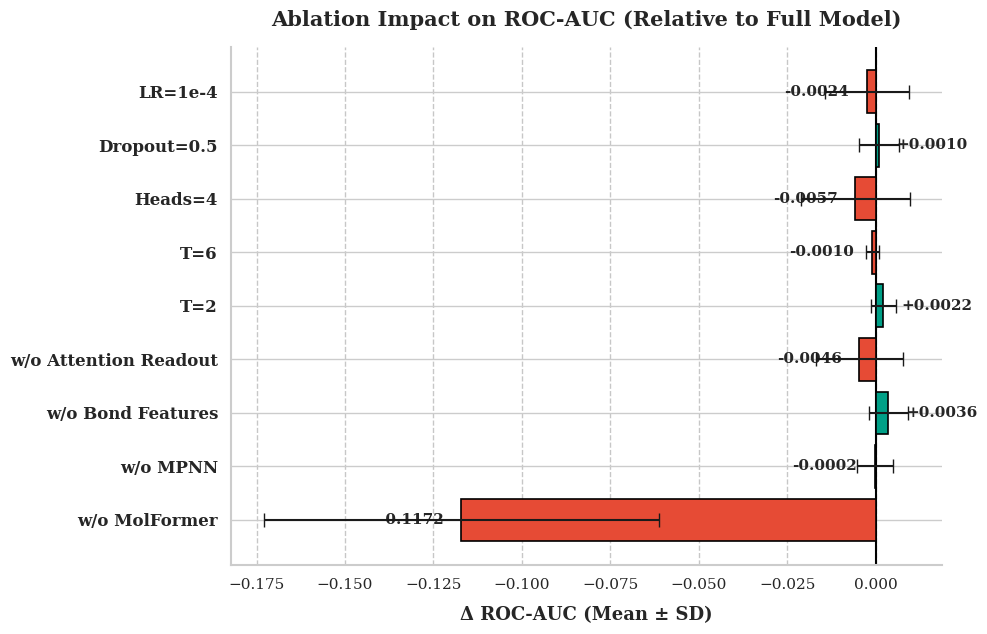

Saved aggregated metrics to results/experiment3_5fold_results.csv


In [8]:
metrics_summary_mean = {}
metrics_summary_std = {}

for name, metrics_lists in results_all_folds.items():
    metrics_summary_mean[name] = {k: np.mean(v) for k, v in metrics_lists.items()}
    metrics_summary_std[name] = {k: np.std(v) for k, v in metrics_lists.items()}

print("\n" + "=" * 90)
print("  EXPERIMENT 3 ABLATION RESULTS SUMMARY (Bemis-Murcko 5-Fold CV)")
print("=" * 90)
print(f"  {'Ablation Config':<25s} {'ROC-AUC':>14s} {'MCC':>14s} {'F1':>14s} {'Accuracy':>14s}")
print("-" * 90)
for name in metrics_summary_mean.keys():
    m_mean = metrics_summary_mean[name]
    m_std = metrics_summary_std[name]
    roc = f"{m_mean['ROC-AUC']:.4f}±{m_std['ROC-AUC']:.4f}"
    mcc = f"{m_mean['MCC']:.4f}±{m_std['MCC']:.4f}"
    f1 = f"{m_mean['F1']:.4f}±{m_std['F1']:.4f}"
    acc = f"{m_mean['Accuracy']:.4f}±{m_std['Accuracy']:.4f}"
    print(f"  {name:<25s} {roc:>14s} {mcc:>14s} {f1:>14s} {acc:>14s}")
print("=" * 90)

# Extract Delta ROC-AUC across seeds for each config
baseline_name = "Full Model (Baseline)"
baseline_roc_auc_seeds = np.array(results_all_folds[baseline_name]["ROC-AUC"])

config_names = [name for name in results_all_folds.keys() if name != baseline_name]
delta_means = []
delta_stds = []

for name in config_names:
    config_roc_auc_seeds = np.array(results_all_folds[name]["ROC-AUC"])
    deltas = config_roc_auc_seeds - baseline_roc_auc_seeds
    delta_means.append(np.mean(deltas))
    delta_stds.append(np.std(deltas))

plt.figure(figsize=(10, 6.5))
ax = plt.gca()
ax.set_facecolor("white")
ax.grid(axis='x', linestyle='--', alpha=0.7, color='#B0B0B0', zorder=0)

y_pos = np.arange(len(config_names))
colors = ['#E64B35' if d < 0 else '#00A087' for d in delta_means]

bars = ax.barh(y_pos, delta_means, xerr=delta_stds, capsize=5, color=colors, edgecolor='black', linewidth=1.2, zorder=3)
ax.axvline(0, color='black', linewidth=1.5, linestyle='-', zorder=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(config_names, fontweight='bold', fontsize=12, fontfamily='serif')
ax.set_xlabel('Δ ROC-AUC (Mean ± SD)', fontweight='bold', fontsize=13, fontfamily='serif', labelpad=10)
ax.set_title('Ablation Impact on ROC-AUC (Relative to Full Model)', fontweight='bold', fontsize=15, fontfamily='serif', pad=15)

for bar, delta_mean in zip(bars, delta_means):
    offset = 0.005 if delta_mean >= 0 else -0.005
    ha_val = 'left' if delta_mean >= 0 else 'right'
    ax.text(delta_mean + offset, bar.get_y() + bar.get_height()/2, 
             f"{delta_mean:+.4f}", va='center', ha=ha_val, fontweight='bold', fontfamily='serif', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig("results/plots/ablation_deltas_5fold.png", dpi=300, bbox_inches='tight')
plt.show()

# Save final table
results_rows = []
for name in results_all_folds.keys():
    row = {"Ablation Config": name}
    for k in ["ROC-AUC", "MCC", "F1", "Accuracy"]:
        row[k] = f"{metrics_summary_mean[name][k]:.4f}±{metrics_summary_std[name][k]:.4f}"
    if name == baseline_name:
        row["Δ ROC-AUC"] = "Baseline"
    else:
        idx = config_names.index(name)
        row["Δ ROC-AUC"] = f"{delta_means[idx]:+.4f}±{delta_stds[idx]:.4f}"
    results_rows.append(row)

pd.DataFrame(results_rows).to_csv("results/experiment3_5fold_results.csv", index=False)
print("Saved aggregated metrics to results/experiment3_5fold_results.csv")